In [18]:
import torch
import neml2
from pyzag import nonlinear, reparametrization, chunktime
import matplotlib.pyplot as plt
import tqdm

In [19]:
torch.set_default_dtype(torch.double)
if torch.cuda.is_available():
    dev = "cuda:0"
    print("CUDA is available")
    print(f"CUDA version: {torch.version.cuda}")
else:
    dev = "cpu"
    print("CUDA is not available")
device = torch.device(dev)

CUDA is available
CUDA version: 12.8


In [20]:
class SolveStrain(torch.nn.Module):
    """Just integrate the model through some strain history

    Args:
        discrete_equations: the pyzag wrapped model
        nchunk (int): number of vectorized time steps
        rtol (float): relative tolerance to use for Newton's method during time integration
        atol (float): absolute tolerance to use for Newton's method during time integration
        initial_rho_m (float): initial mobile dislocation density (m^-2)
    """

    def __init__(self, discrete_equations, nchunk=1, rtol=1.0e-5, atol=1.0e-3, initial_rho_m=4.51e12):
        super().__init__()
        self.discrete_equations = discrete_equations
        self.nchunk = nchunk
        self.rtol = rtol
        self.atol = atol
        self.initial_rho_m = initial_rho_m

    def forward(self, time, temperature, loading):
        """Integrate through some time/temperature/strain history and return stress
        Args:
            time (torch.tensor): batched times
            temperature (torch.tensor): batched temperatures
            loading (torch.tensor): loading conditions, which are the input strain in the first base index and then the stress (zero) in the remainder
        """
        solver = nonlinear.RecursiveNonlinearEquationSolver(
            self.discrete_equations,
            step_generator=nonlinear.StepGenerator(self.nchunk),
            predictor=nonlinear.PreviousStepsPredictor(),
            nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=self.rtol, atol=self.atol),
        )
        
        control = torch.zeros_like(loading)
        control[...,1:] = 1.0

        # Setup
        forces = self.discrete_equations.forces_asm.assemble_by_variable(
            {
                "forces/t": time,
                "forces/control": control,
                "forces/T": temperature,
                "forces/fixed_values": loading
            }
        ).torch()

        # Initialize state with non-zero rho_m to seed plastic flow.
        # assemble_by_variable fills unspecified variables with zeros automatically.
        state0 = self.discrete_equations.state_asm.assemble_by_variable(
            {
                "state/internal/rho_m": torch.full(
                    forces.shape[1:-1] + (1,), self.initial_rho_m, device=forces.device
                )
            }
        ).torch()

        result = nonlinear.solve_adjoint(solver, state0, len(forces), forces)
        
        # Check if result is empty or invalid
        if result is None or len(result) == 0:
            raise RuntimeError("Solver returned empty result - integration failed")

        return result[...,0:1]

In [21]:
nchunk = 50
nmodel = neml2.load_model("new_model_test.i", "implicit_rate")
nmodel.to(device=device)
print(nmodel)
model = SolveStrain(neml2.pyzag.NEML2PyzagModel(nmodel, exclude_parameters=["E_X", "E_Y", "elasticity_nu", "C_X", "g_X", "athermal_L", "athermal_b", "flow_rate_b", "rho_m_rate_L", "shear_athermal_m", "shear_eff_m",
                                                                            "sy_X", "v_disl_Bk", "v_disl_L", "v_disl_a", "v_disl_b", "v_disl_h", "v_disl_pierls_stress", "G_X", "G_Y", "v_disl_p", "v_disl_q", "k1_X", "k2_X",
                                                                            "athermal_alpha", "v_disl_T_ref", "v_disl_Bk", "v_disl_k_B", "v_disl_activation_energy", "T_0_X", "T_ref_X"]))

Name:       implicit_rate
Input:      forces/control [SR2]
            forces/fixed_values [SR2]
            forces/t [Scalar]
            old_forces/control [SR2]
            old_forces/fixed_values [SR2]
            old_forces/t [Scalar]
            old_state/internal/Kp [SR2]
            old_state/internal/X [SR2]
            old_state/internal/rho_m [Scalar]
            old_state/mixed_state [SR2]
            state/internal/Kp [SR2]
            state/internal/X [SR2]
            state/internal/rho_m [Scalar]
            state/mixed_state [SR2]
Output:     residual/internal/Kp [SR2]
            residual/internal/X [SR2]
            residual/internal/rho_m [Scalar]
            residual/mixed_state [SR2]
Parameters: athermal_alpha [Scalar][Double][cuda:0]
            athermal_b [Scalar][Double][cuda:0]
            athermal_shear_modulus [Scalar][Double][cuda:0]
            elasticity_E [Scalar][Double][cuda:0]
            elasticity_nu [Scalar][Double][cuda:0]
            flow_rate_b 

In [ ]:
nbatch = 1
ntime = 100
max_strain = 0.4
rate = 1e-4
temp = 2956 #K
time = torch.zeros((ntime, nbatch, 1), device=device)
temperature = torch.zeros((ntime, nbatch, 1), device=device)
loading = torch.zeros((ntime, nbatch, 6), device=device)

time_values = torch.linspace(0.0, max_strain / rate, ntime, device=device)
strain_values = torch.linspace(0.0, max_strain, ntime, device=device)

time[:,:,0] = time_values.unsqueeze(1)
loading[:,:,0] = strain_values.unsqueeze(1)
temperature[:,:,0] = temp

print(f"\n--- Full Input Tensors ---\ntime: {time.shape}\ntemperature: {temperature.shape}\nloading: {loading.shape}")



--- Full Input Tensors ---
time: torch.Size([100, 1, 1])
temperature: torch.Size([100, 1, 1])
loading: torch.Size([100, 1, 6])


In [23]:
with torch.no_grad():
    stress = model(time, temperature, loading)
print(stress)
print(stress.shape)

tensor([[[   0.0000]],

        [[ 202.0202]],

        [[ 404.0404]],

        [[ 606.0606]],

        [[ 808.0808]],

        [[1010.1010]],

        [[1212.1212]],

        [[1414.1414]],

        [[1616.1616]],

        [[1818.1818]],

        [[2020.2020]],

        [[2222.2222]],

        [[2424.2424]],

        [[2626.2626]],

        [[2828.2828]],

        [[3030.3030]],

        [[3232.3232]],

        [[3434.3434]],

        [[3636.3636]],

        [[3838.3838]],

        [[4040.4040]],

        [[4242.4242]],

        [[4444.4444]],

        [[4646.4646]],

        [[4848.4848]],

        [[5050.5051]],

        [[5252.5253]],

        [[5454.5455]],

        [[5656.5657]],

        [[5858.5859]],

        [[6060.6061]],

        [[6262.6263]],

        [[6464.6465]],

        [[6666.6667]],

        [[6868.6869]],

        [[6868.6869]],

        [[6868.6869]],

        [[6868.6869]],

        [[6868.6869]],

        [[6868.6869]],

        [[6868.6869]],

        [[6868.6

Text(0, 0.5, 'Stress [MPa]')

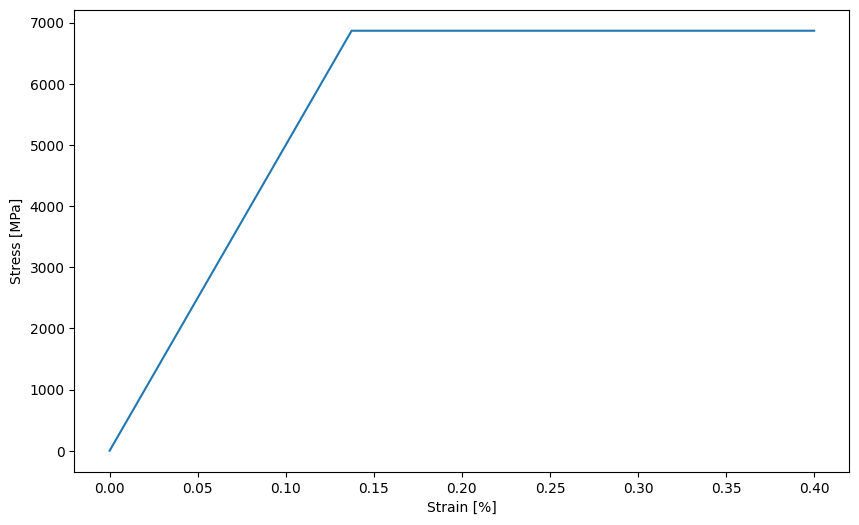

In [24]:
plt.figure(figsize=(10,6))
plt.plot(loading[...,0].cpu().numpy(), stress[...,0].cpu().numpy())
plt.xlabel('Strain [%]')
plt.ylabel('Stress [MPa]')

Available state variables:
  state/internal/Kp
  state/internal/X
  state/internal/rho_m
  state/mixed_state
rho_m: start=4.510000e+12, end=4.509571e+12
||X||: start=0.000000e+00, end=0.000000e+00
||Kp||: start=0.000000e+00, end=0.000000e+00


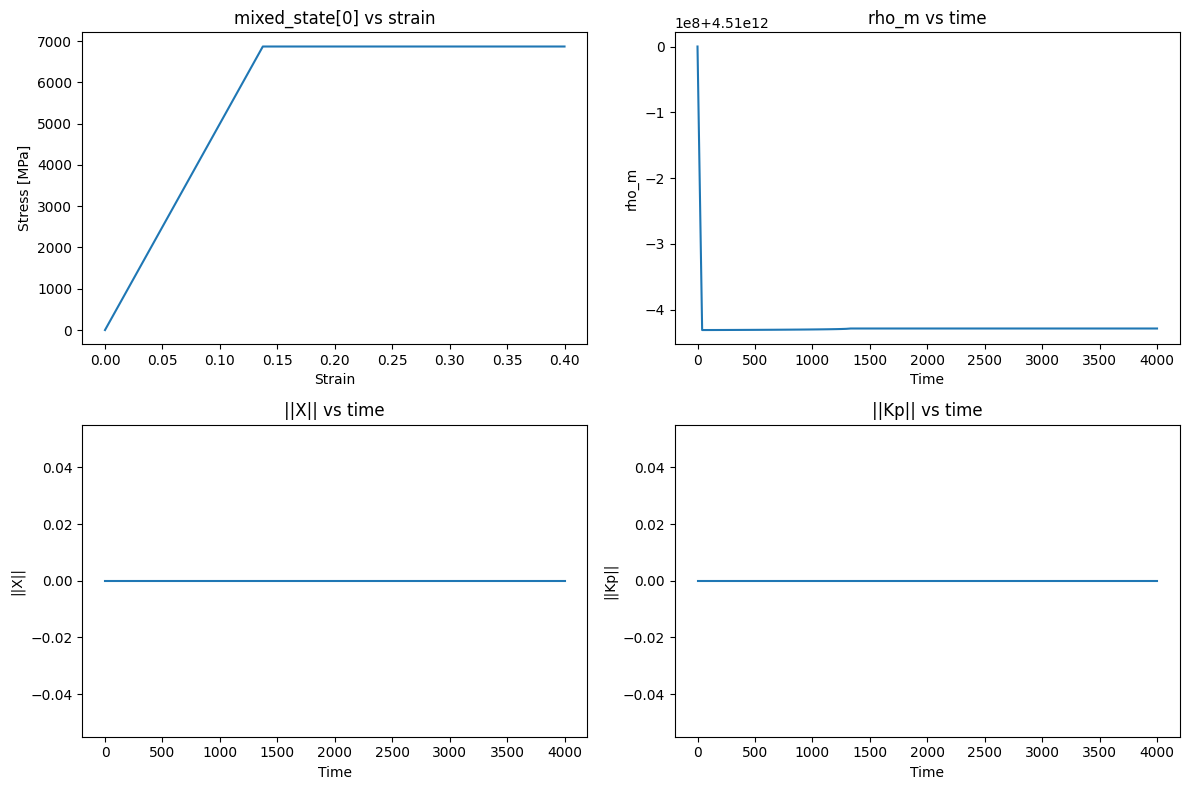

In [25]:
# Debug: inspect internal-variable evolution over time
with torch.no_grad():
    dbg_solver = nonlinear.RecursiveNonlinearEquationSolver(
        model.discrete_equations,
        step_generator=nonlinear.StepGenerator(model.nchunk),
        predictor=nonlinear.PreviousStepsPredictor(),
        nonlinear_solver=chunktime.ChunkNewtonRaphson(rtol=model.rtol, atol=model.atol),
    )

    dbg_control = torch.zeros_like(loading)
    dbg_control[..., 1:] = 1.0

    dbg_forces = model.discrete_equations.forces_asm.assemble_by_variable(
        {
            "forces/t": time,
            "forces/control": dbg_control,
            "forces/T": temperature,
            "forces/fixed_values": loading,
        }
    ).torch()

    dbg_state0 = model.discrete_equations.state_asm.assemble_by_variable(
        {
            "state/internal/rho_m": torch.full(
                dbg_forces.shape[1:-1] + (1,), model.initial_rho_m, device=dbg_forces.device
            )
        }
    ).torch()

    dbg_results = nonlinear.solve_adjoint(dbg_solver, dbg_state0, len(dbg_forces), dbg_forces)

# Convert VariableName keys to strings for safe filtering/sorting/indexing
state_hist_raw = model.discrete_equations.state_asm.split_by_variable(neml2.Tensor(dbg_results, 2))
state_hist = {str(k): v for k, v in state_hist_raw.items()}

available_names = sorted(state_hist.keys())
print("Available state variables:")
for name in available_names:
    print(" ", name)


def get_hist(name):
    return state_hist[name].torch() if name in state_hist else None

rho_m = get_hist("state/internal/rho_m")
X = get_hist("state/internal/X")
Kp = get_hist("state/internal/Kp")
stress_state = get_hist("state/mixed_state")

# Convert to 1D histories for the first batch item
strain_hist = loading[:, 0, 0].detach().cpu()
time_hist = time[:, 0, 0].detach().cpu()
stress11 = stress_state[:, 0, 0].detach().cpu() if stress_state is not None else None
rho_m_hist = rho_m[:, 0, 0].detach().cpu() if rho_m is not None else None
x_norm_hist = torch.linalg.norm(X[:, 0, :], dim=-1).detach().cpu() if X is not None else None
kp_norm_hist = torch.linalg.norm(Kp[:, 0, :], dim=-1).detach().cpu() if Kp is not None else None

if rho_m_hist is not None:
    print(f"rho_m: start={rho_m_hist[0].item():.6e}, end={rho_m_hist[-1].item():.6e}")
if x_norm_hist is not None:
    print(f"||X||: start={x_norm_hist[0].item():.6e}, end={x_norm_hist[-1].item():.6e}")
if kp_norm_hist is not None:
    print(f"||Kp||: start={kp_norm_hist[0].item():.6e}, end={kp_norm_hist[-1].item():.6e}")

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

if stress11 is not None:
    ax[0, 0].plot(strain_hist.numpy(), stress11.numpy())
    ax[0, 0].set_title("mixed_state[0] vs strain")
    ax[0, 0].set_xlabel("Strain")
    ax[0, 0].set_ylabel("Stress [MPa]")
else:
    ax[0, 0].text(0.1, 0.5, "state/mixed_state not available")

if rho_m_hist is not None:
    ax[0, 1].plot(time_hist.numpy(), rho_m_hist.numpy())
    ax[0, 1].set_title("rho_m vs time")
    ax[0, 1].set_xlabel("Time")
    ax[0, 1].set_ylabel("rho_m")
else:
    ax[0, 1].text(0.1, 0.5, "state/internal/rho_m not available")

if x_norm_hist is not None:
    ax[1, 0].plot(time_hist.numpy(), x_norm_hist.numpy())
    ax[1, 0].set_title("||X|| vs time")
    ax[1, 0].set_xlabel("Time")
    ax[1, 0].set_ylabel("||X||")
else:
    ax[1, 0].text(0.1, 0.5, "state/internal/X not available")

if kp_norm_hist is not None:
    ax[1, 1].plot(time_hist.numpy(), kp_norm_hist.numpy())
    ax[1, 1].set_title("||Kp|| vs time")
    ax[1, 1].set_xlabel("Time")
    ax[1, 1].set_ylabel("||Kp||")
else:
    ax[1, 1].text(0.1, 0.5, "state/internal/Kp not available")

plt.tight_layout()
plt.show()